# Aprendizaje Estadístico y Data Mining

## Práctica 4: Taxonomía de	coches

### Objetivo
Una empresa de importación de coches pretende hacer una renovación de sus instalaciones. Una de las propuestas es disponer de robots que permitan distribuir en los almacenes los coches de forma más eficiente. Para ello se dispone del archivo csv ***“cars”*** con las características de los distintos coches. Crear un modelo que agrupe los coches y establezca como se relacionan entre ellos jerárquicamente.

Instalar Librerías:

In [116]:
#%pip install pandas scikit-learn numpy matplotlib scipy ipympl

Importar Librerías:

In [ ]:
import pandas as pd # type: ignore
import scipy.cluster.hierarchy as sch # type: ignore
import matplotlib.pyplot as plt # type: ignore
import numpy as np # type: ignore
from sklearn.preprocessing import OneHotEncoder # type: ignore
from sklearn.preprocessing import StandardScaler # type: ignore
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage # type: ignore


**Enunciado:** Utiliza varias configuraciones para el modelo que más se adapte y teniendo en cuenta los tipos de distancias entre elementos. ¿Cuál es la k del modelo?

**Solución**

#### Carga y preprocesamiento del dataset

En primer lugar, cargaremos el dataset con la información necesaria. Una vez cargado el dataset, tendremos que transformar las variables categóricas a datos numéricos. Como a priori no parecen haber muchos datos de cada tipo, utilizaremos **One-Hot Encoding**, con el que transformaeros las variables categóricas a binario. Si viesemos que la dimensionalidad aumenta demasiado, podríamos considerar utilizar el ***Label-Encoding***.

In [ ]:
data = pd.read_csv("data/cars.csv", header=None)
# Agregamos etiquetas a las columnas para su posterior tratamiento
data.columns = ['precio_compra', 'precio_mantenimiento', 'puertas', 'plazas', 'tamaño', 'seguridad', 'clase']
# Remplazamos los atributos de moreo y 5more por datos numéricos
data['puertas'] = data['puertas'].replace('5more', 5).astype(int)
data['plazas'] = data['plazas'].replace('more', 5).astype(int)


df = pd.DataFrame(data)


# Transformación
encoder = OneHotEncoder(sparse_output=False)
categorical_columns = ['precio_compra', 'precio_mantenimiento', 'tamaño', 'seguridad', 'clase']

df_encoded = pd.DataFrame(encoder.fit_transform(df[categorical_columns]))

df_encoded.columns = df_encoded.columns.astype(str)

# Juntamos los datos categóricos ya transformados con los numéricos
df_numeric = df[['puertas', 'plazas']].join(df_encoded)
df_numeric = df_numeric.apply(pd.to_numeric, errors='coerce')

Una vez tenemos las variables categóricas codificadas en binario, podemos proceder con la normalización de los datos.

In [ ]:
# Normalizamos los datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

#### Elección de parámetros
Para la elección de parámetros de nuestro modelo, probaremos con distintos métodos de enlace, así como con diferentes distancias, para posteriormente, evaluar y elegir cual podría ser la mejor elección.

In [ ]:
metodos_enlace = ['single', 'complete', 'average', 'ward']
distancias_max = [1, 2, 3, 4, 5, 6, 7, 8]
clusters_metodo = {}

for method in metodos_enlace:
    Z = sch.linkage(df_scaled, method=method)
    for max_d in distancias_max:
        clusters = fcluster(Z, max_d, criterion='distance')
        k = len(np.unique(clusters))
        clusters_metodo[(method, max_d)] = k
        print(f"Método de Enlace: {method} - max_d: {max_d} - k (número de clústeres): {k}")

Método de Enlace: single - max_d: 1 - k (número de clústeres): 322
Método de Enlace: single - max_d: 2 - k (número de clústeres): 240
Método de Enlace: single - max_d: 3 - k (número de clústeres): 222
Método de Enlace: single - max_d: 4 - k (número de clústeres): 3
Método de Enlace: single - max_d: 5 - k (número de clústeres): 3
Método de Enlace: single - max_d: 6 - k (número de clústeres): 1
Método de Enlace: single - max_d: 7 - k (número de clústeres): 1
Método de Enlace: single - max_d: 8 - k (número de clústeres): 1
Método de Enlace: complete - max_d: 1 - k (número de clústeres): 1042
Método de Enlace: complete - max_d: 2 - k (número de clústeres): 594
Método de Enlace: complete - max_d: 3 - k (número de clústeres): 322
Método de Enlace: complete - max_d: 4 - k (número de clústeres): 223
Método de Enlace: complete - max_d: 5 - k (número de clústeres): 92
Método de Enlace: complete - max_d: 6 - k (número de clústeres): 38
Método de Enlace: complete - max_d: 7 - k (número de clústere

Tras probar diversos parámetros, como el **método de enlace** y la **distancia máxima**, hemos decidido coger la siguiente configuración:
- **Método de Enlace:** Average
- **Distancia Máxima:** 6
Esto debido a la menor agresividad a la hora de disminuir los clústerers, lo que nos hace pensar que igual las agrupaciones son menos agresivas y por ello, más representativas.   

Con esta configuración, obtenemos un total de **4 clústeres** (k = 4).

#### Creación del Dendograma

A continuación, dibujaremos el dendograma, utilizando los parámetros utilizados anteriormente. Para ello, una vez se haya completado el gráfico, realizaremos una línea de corte en $y = 6$, siguiendo la configuración obtenida en el apartado anterior.

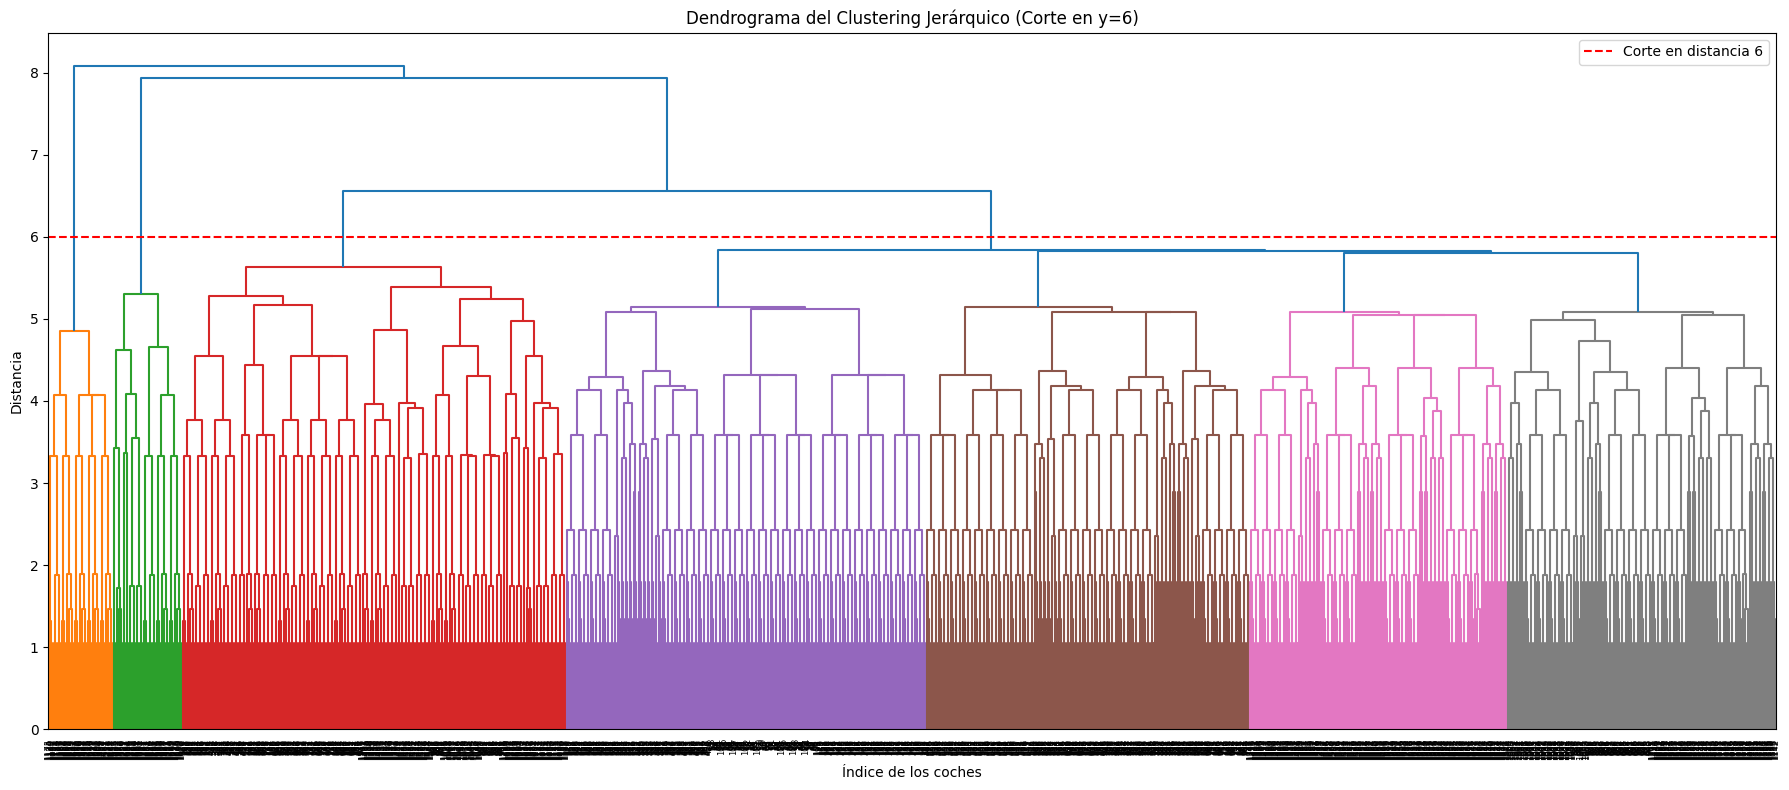

In [121]:
Z = linkage(df_scaled, method='average')

plt.figure(figsize=(18, 8))
dendrogram(Z, leaf_rotation=90., leaf_font_size=6.)
plt.axhline(y=6, c='red', linestyle='--', label='Corte en distancia 6')
plt.title("Dendrograma del Clustering Jerárquico (Corte en y=6)")
plt.xlabel("Índice de los coches")
plt.ylabel("Distancia")
plt.legend()
plt.tight_layout()
plt.show()

Una vez tenemos el dendograma dibujado, podemos proceder a buscar relaciones interesantes con los clústeres asignados. Para ello, añadiremos el clúster al DataFrame, de tal manera que podamos observar características comúmes y predominantes en los distintos grupos. Una vez tengamos los clústeres agreado al DataFrame, podemos calcular la moda de cada clúster y sacar una tabla con los atributos *generales* de cada grupo.

In [ ]:
df['cluster'] = fcluster(Z, 6, criterion='distance')
display(df.groupby('cluster').agg(lambda x: x.value_counts().index[0]))

,precio_compra,precio_mantenimiento,puertas,plazas,tamaño,seguridad,clase
cluster,,,,,,,
1,low,med,4,5,big,high,vgood
2,low,low,3,4,med,med,good
3,med,med,4,4,big,high,acc
4,vhigh,vhigh,2,2,small,low,unacc


Con esta tabla, podemos ver varias relaciones interesantes, y formular diferentes hipótesis:   

- **Clúster 4:** El precio de compra y de mantenimiento son muy altos, además de tener únicamente 2 puertas con 2 plazas, con un tamaño pequeño. Dadas estas características podemos pensar que estos coches son super deportivos, de ahí su elevado precio y su número de plazas.  

- **Clúster 3:** En este caso, tenemos una clase de coche estándar, de gamma media, que parece estar más enfocado a la funcionalidad. Sus precios son medios, y tienen las plazas justas y necesarias.

- **Clúster 2:** Este es el grupo de coches más económico, tanto en precio como en mantenimiento. Podrían ser coches antiguos, coches eficientes, adecuados posiblemente para alguien que esté empezando a conducir.

- **Clúster 1:** Por último, nos encontramos con el tipo de coche con más plazas, y con un tamaño grande. Su precio bajo y precio de mantenimiento medio, podría adecuarse a un coche eficiente, que a juzgar por sus números de plazas, podrían ser coches familiares, SUVS o coches de ese estilo.